### Setup

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import keras
import tensorflow as tf
import pathlib
import keras_hub
from PIL import Image

C:\Users\PRASHANTH N\PycharmProjects\Kaggle-s-Dogs-vs.-Cats-Redux-Kernels-Edition\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Quick health check to prove it works:
print("Is PyTorch utilizing the GPU?:", torch.cuda.is_available())
print("Device Name:", torch.cuda.get_device_name(0))

Is PyTorch utilizing the GPU?: True
Device Name: NVIDIA GeForce RTX 5050 Laptop GPU


In [4]:
model_name = "catsvsdogsfinetuned1.keras"
batch_size = 32
input_shape = 256
image_size = (input_shape, input_shape)

### Load Dataset

In [5]:
dataset_dir = "Datasets"
original_dir = pathlib.Path(f"{dataset_dir}/train")
new_base_dir = pathlib.Path(f"{dataset_dir}/dogs_vs_cats_small")

In [6]:
train_dataset = keras.utils.image_dataset_from_directory(new_base_dir / "sub_train", image_size=image_size, batch_size=batch_size)
validation_dataset = keras.utils.image_dataset_from_directory(new_base_dir / "sub_validation", image_size=image_size, batch_size=batch_size)
test_dataset = keras.utils.image_dataset_from_directory(new_base_dir / "sub_test", image_size=image_size, batch_size=batch_size)

Found 15000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [7]:
data_augmentation_layers = [
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.2),
]

def data_augmentation(images, targets):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images, targets

augmented_train_dataset = train_dataset.map(data_augmentation, num_parallel_calls=8)
augmented_train_dataset = augmented_train_dataset.prefetch(tf.data.AUTOTUNE)

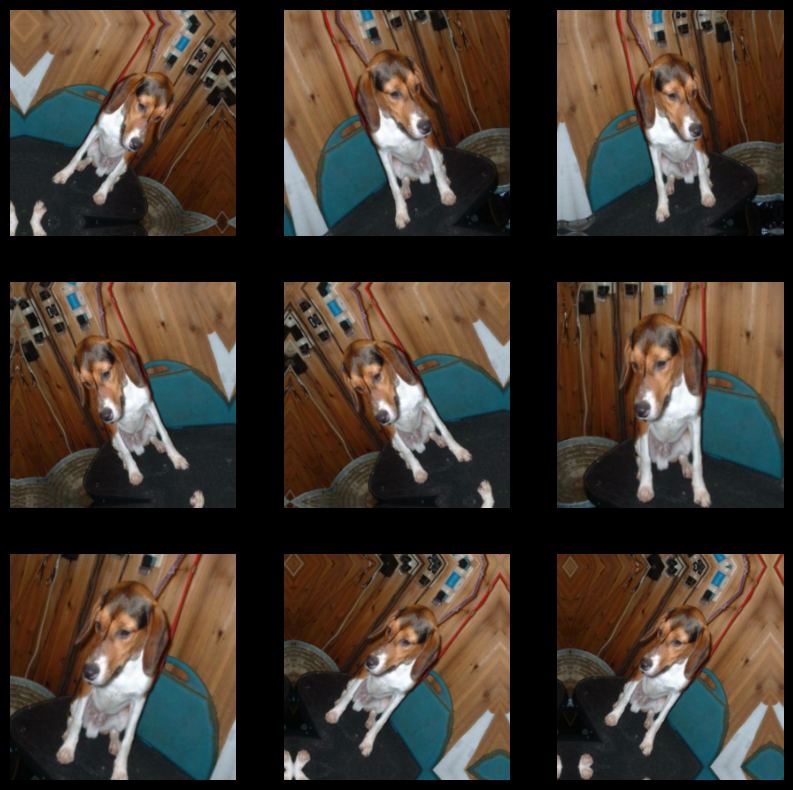

In [8]:
plt.figure(figsize=(10, 10))
for image_batch, _ in train_dataset.take(1):
    image = image_batch[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image, _ = data_augmentation(image, None)
        augmented_image = keras.ops.convert_to_numpy(augmented_image)
        plt.imshow(augmented_image.astype("uint8"))
        plt.axis("off")

### Load Model

In [9]:
conv_base = keras_hub.models.Backbone.from_preset("xception_41_imagenet")
#conv_base.summary()

In [10]:
preprocessor = keras.Sequential([keras.layers.Resizing(input_shape, input_shape, interpolation="bilinear", crop_to_aspect_ratio=True), keras.layers.Rescaling(scale=1.0 / 127.5, offset=-1.0)])

### Finetune a pretrained Model

In [11]:
conv_base = keras_hub.models.Backbone.from_preset("xception_41_imagenet", trainable=False)
#conv_base.summary()

In [12]:
conv_base.trainable = True
for layer in conv_base.layers[:-7]:
    layer.trainable = False

In [13]:
inputs = keras.Input(shape=(input_shape, input_shape, 3))
x = preprocessor(inputs)
x = conv_base(x)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(256)(x)
x = keras.layers.Dropout(0.25)(x)
x = keras.layers.Dense(64)(x)
x = keras.layers.Dropout(0.25)(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)

In [ ]:
model.compile(loss="binary_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=1e-5), metrics=["accuracy"])

callbacks = [keras.callbacks.ModelCheckpoint(filepath=model_name, save_best_only=True, monitor="val_loss"), keras.callbacks.EarlyStopping(monitor="val_loss", patience=5)]

history = model.fit(augmented_train_dataset, epochs=100, validation_data=validation_dataset, callbacks=callbacks)

C:\Users\PRASHANTH N\PycharmProjects\Kaggle-s-Dogs-vs.-Cats-Redux-Kernels-Edition\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 237s 499ms/step - accuracy: 0.9474 - loss: 0.1799 - val_accuracy: 0.9914 - val_loss: 0.0403
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 693s 1s/step - accuracy: 0.9783 - loss: 0.0655 - val_accuracy: 0.9918 - val_loss: 0.0290
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 1041s 2s/step - accuracy: 0.9795 - loss: 0.0532 - val_accuracy: 0.9924 - val_loss: 0.0259
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 1425s 3s/step - accuracy: 0.9828 - loss: 0.0466 - val_accuracy: 0.9928 - val_loss: 0.0244
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 1507s 3s/step - accuracy: 0.9841 - loss: 0.0454 - val_accuracy: 0.9928 - val_loss: 0.0231
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 1366s 3s/step - accuracy: 0.9835 - loss: 0.0431 - val_accuracy: 0.9924 - val_loss: 0.0229
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 1804s 4s/step - accuracy: 0.9851 - loss: 0.0387 - val_accuracy: 0.9928 - val_loss: 0.0220
Epoch 8/100
177/469 ━━━━━━━━━━━━━━━━━━━━ 22:03 5s/step - accuracy: 0.9885 - loss: 

### Evaluate

In [9]:
model = keras.models.load_model(model_name)
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")
print(f"Test loss: {test_loss:.3f}")

C:\Users\PRASHANTH N\PycharmProjects\Kaggle-s-Dogs-vs.-Cats-Redux-Kernels-Edition\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 322 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(store)


157/157 ━━━━━━━━━━━━━━━━━━━━ 31s 180ms/step - accuracy: 0.9906 - loss: 0.0265
Test accuracy: 0.991
Test loss: 0.026


### Submission

In [10]:
dataset_dir = "Datasets"
submission_dir = pathlib.Path(f"{dataset_dir}/test")

In [11]:
image_paths = sorted(submission_dir.glob("*.jpg"), key=lambda x: int(x.stem))
print(f"Found {len(image_paths)} images")
images = []
for path in image_paths:
    img = Image.open(path).convert("RGB")
    img = img.resize(image_size)
    images.append(np.array(img))
sub_images = np.array(images)
print("Dataset shape:", sub_images.shape)

Found 12500 images
Dataset shape: (12500, 256, 256, 3)


0 Datasets\test\1.jpg


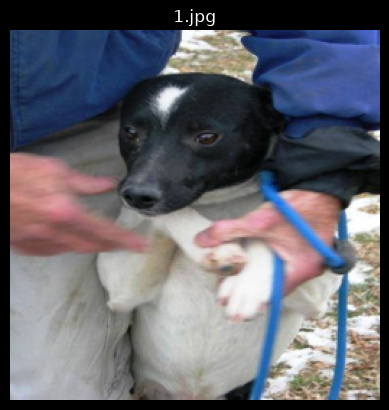

1 Datasets\test\2.jpg


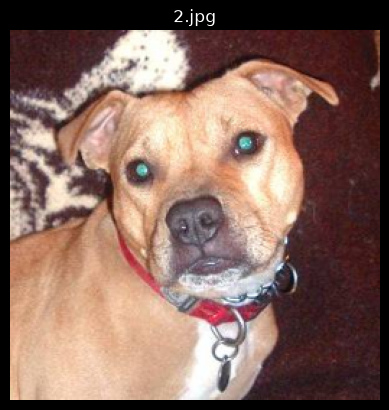

2 Datasets\test\3.jpg


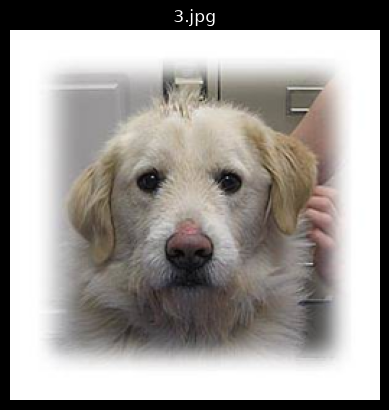

In [12]:
for i in range(3):
    print(i, image_paths[i])
    plt.imshow(sub_images[i].astype("uint8"))
    plt.title(image_paths[i].name)
    plt.axis("off")
    plt.show()

In [13]:
test_model2 = keras.models.load_model(model_name)
predictions2 = test_model2.predict(sub_images)
preds = [i[0] for i in predictions2.tolist()]
submission = {"id": list(range(1, 12501)), "label": preds}
df = pd.DataFrame(submission)
df.to_csv("submission_finetuned_new.csv", index=False)

391/391 ━━━━━━━━━━━━━━━━━━━━ 67s 171ms/step


end